### Setup

In [1]:
import matplotlib.pyplot as plt
import scipy as sc
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os
import torch
from tqdm import tqdm
import scipy.optimize as opt
import subprocess

In [2]:
sys.path.insert(0, os.getcwd())

from model import GPTConfig, GPT
from lib.utils import get_batch, get_ckpt_model, two_phase_opt

In [3]:
dataset='shakespeare_char'

## NanoGPT Experiments

### Experiment 1: MHA LRB

In [4]:
n_head_choices = [1,2,3,4,5,6,7,8,16,32,64]
n_samples = 350
d=128
ckpt_dir="experiments"

In [5]:
for n_head in n_head_choices:
    head_size = d//n_head
    train_cmd = [
        "python", "train.py", "config/train_shakespeare_char.py",
        f"--head_size={head_size}",
        f"--n_head={n_head}",
        f"--out_dir={ckpt_dir}",
        f"--out_fname=ckpt_h{n_head}.pt",
        f"--device=xpu",
    ]
    print(' '.join(train_cmd))
    subprocess.run(train_cmd, stdout=subprocess.DEVNULL)

python train.py config/train_shakespeare_char.py --head_size=128 --n_head=1 --out_dir=experiments --out_fname=ckpt_h1.pt --device=xpu


Training: 5001it [01:33, 53.28it/s, loss=1.9190]                          


python train.py config/train_shakespeare_char.py --head_size=64 --n_head=2 --out_dir=experiments --out_fname=ckpt_h2.pt --device=xpu


Training: 5001it [01:45, 47.43it/s, loss=1.8894]                          


python train.py config/train_shakespeare_char.py --head_size=42 --n_head=3 --out_dir=experiments --out_fname=ckpt_h3.pt --device=xpu


...

Training: 5001it [01:45, 47.53it/s, loss=1.8928]                          


python train.py config/train_shakespeare_char.py --head_size=4 --n_head=32 --out_dir=experiments --out_fname=ckpt_h32.pt --device=xpu


Training: 5001it [01:53, 43.95it/s, loss=1.8995]                          


python train.py config/train_shakespeare_char.py --head_size=2 --n_head=64 --out_dir=experiments --out_fname=ckpt_h64.pt --device=xpu


Training: 5001it [01:53, 44.20it/s, loss=1.9044]                          


In [6]:
rows = []
for n_head in n_head_choices:
    ckpt_fname = f"ckpt_h{n_head}.pt"
    model = get_ckpt_model(ckpt_fname, ckpt_dir=ckpt_dir)
    batch_size = model.config.batch_size
    n = model.config.block_size

    print(f"Evaluating {ckpt_fname}")
    
    losses = np.zeros(n_samples)
    for i in tqdm(range(n_samples)):
        X, Y = get_batch('eval', os.path.join('data', dataset), 'cpu', n, batch_size)
        logits, loss = model(X, Y)
        losses[i]= loss
            
    rows.append({
        'head_size': model.config.head_size,
        'n_head': n_head,
        'perplexity': np.exp(np.mean(losses)),
    })
    
df1 = pd.DataFrame(rows)
df1.set_index('n_head', inplace=True)
df1.to_csv("experiments/ex1_results.csv")

Evaluating ckpt_h1.pt


100%|██████████| 350/350 [00:04<00:00, 85.78it/s] 


Evaluating ckpt_h2.pt


100%|██████████| 350/350 [00:06<00:00, 56.82it/s]


Evaluating ckpt_h3.pt


...

100%|██████████| 350/350 [00:06<00:00, 52.71it/s]


Evaluating ckpt_h32.pt


100%|██████████| 350/350 [00:05<00:00, 68.53it/s]


Evaluating ckpt_h64.pt


100%|██████████| 350/350 [00:06<00:00, 52.21it/s]


### Experiment 2: FMHA LRB

In [7]:
n_head_choices = [1,2,3,4,5,6,7,8]
n_samples = 350
d=128
ckpt_dir="experiments"

In [8]:
for n_head in n_head_choices:
    head_size = 40 # > n=32
    train_cmd = [
        "python", "train.py", "config/train_shakespeare_char.py",
        f"--head_size={head_size}",
        f"--n_head={n_head}",
        f"--out_dir={ckpt_dir}",
        f"--out_fname=ckpt_fmha_h{n_head}.pt",
        f"--device=xpu",
    ]
    print(' '.join(train_cmd))
    subprocess.run(train_cmd, stdout=subprocess.DEVNULL)

python train.py config/train_shakespeare_char.py --head_size=40 --n_head=1 --out_dir=experiments --out_fname=ckpt_fmha_h1.pt --device=xpu


Training: 5001it [01:36, 51.80it/s, loss=1.9663]                          


python train.py config/train_shakespeare_char.py --head_size=40 --n_head=2 --out_dir=experiments --out_fname=ckpt_fmha_h2.pt --device=xpu


Training: 5001it [01:43, 48.54it/s, loss=1.9235]                          


python train.py config/train_shakespeare_char.py --head_size=40 --n_head=3 --out_dir=experiments --out_fname=ckpt_fmha_h3.pt --device=xpu


...

Training: 5001it [01:43, 48.24it/s, loss=1.8932]                          


python train.py config/train_shakespeare_char.py --head_size=40 --n_head=7 --out_dir=experiments --out_fname=ckpt_fmha_h7.pt --device=xpu


Training: 5001it [01:50, 45.39it/s, loss=1.8754]                          


python train.py config/train_shakespeare_char.py --head_size=40 --n_head=8 --out_dir=experiments --out_fname=ckpt_fmha_h8.pt --device=xpu


Training: 5001it [01:42, 48.76it/s, loss=1.8874]                          


In [9]:
rows = []
for n_head in n_head_choices:
    ckpt_fname = f"ckpt_fmha_h{n_head}.pt"
    model = get_ckpt_model(ckpt_fname, ckpt_dir=ckpt_dir)
    assert(model.config.n_embd == d)
    
    print(f"Evaluating {ckpt_fname}")
    
    losses = np.zeros(n_samples)
    for i in tqdm(range(n_samples)):
        X, Y = get_batch('eval', os.path.join('data', dataset), 'cpu', n, batch_size)
        logits, loss = model(X, Y)
        losses[i]= loss

    rows.append({
        'n_head': n_head,
        'perplexity': np.exp(np.mean(losses)),
    })
df2 = pd.DataFrame(rows)
df2.to_csv("experiments/ex2_results.csv")

Evaluating ckpt_fmha_h1.pt


100%|██████████| 350/350 [00:03<00:00, 97.85it/s] 


Evaluating ckpt_fmha_h2.pt


100%|██████████| 350/350 [00:02<00:00, 126.58it/s]


Evaluating ckpt_fmha_h3.pt


...

100%|██████████| 350/350 [00:04<00:00, 84.06it/s]


Evaluating ckpt_fmha_h7.pt


100%|██████████| 350/350 [00:05<00:00, 68.17it/s]


Evaluating ckpt_fmha_h8.pt


100%|██████████| 350/350 [00:05<00:00, 62.08it/s]


### Experiment 3: Equivalent Non-Identifiable Distribution for MHA

In [17]:
n_head_choices = [5,8,16,32,64]
n_samples = 100
d=128
ckpt_dir="experiments"

In [18]:
rows = []
for n_head in n_head_choices:
    ckpt_fname = f"ckpt_h{n_head}.pt"
    model = get_ckpt_model(ckpt_fname, ckpt_dir=ckpt_dir)
    h = model.config.n_head
    n = model.config.block_size
    hs = model.config.head_size
    batch_size = model.config.batch_size
    
    assert(model.config.n_embd == d)
    assert(hs < n)

    print(f"Evaluating {ckpt_fname}")
    
    opt_vals = []
    losses = np.zeros(n_samples)
    for i in tqdm(range(n_samples)):
        X, Y = get_batch('eval', os.path.join('data', dataset), 'cpu', n, batch_size)
        A,T,v = model.get_matricies(X,0)
        res = two_phase_opt(n,A,T,X.numpy(),col_idx=0)
        if(res != None):
            opt_vals.append(res[0])

    if(len(opt_vals) == 0):
        min_opt_val = 0
    else:
        min_opt_val = np.min(np.array(opt_vals))

    rows.append({
        'head_size': d//n_head,
        'n_head': n_head,
        'perplexity': np.exp(np.mean(losses)),
        'min_opt_val': min_opt_val,
    })
    
df3 = pd.DataFrame(rows)
df3['log_min_opt_val'] = np.log(df3['min_opt_val'])
df3.to_csv("experiments/ex3_results.csv")

Evaluating ckpt_h5.pt


100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


Evaluating ckpt_h8.pt


100%|██████████| 100/100 [03:39<00:00,  2.19s/it]


Evaluating ckpt_h16.pt


100%|██████████| 100/100 [05:43<00:00,  3.44s/it]


Evaluating ckpt_h32.pt


100%|██████████| 100/100 [06:02<00:00,  3.63s/it]


Evaluating ckpt_h64.pt


100%|██████████| 100/100 [06:26<00:00,  3.87s/it]


### Experiment 4: Removing the Low Rank Bottleneck

In [25]:
n_samples = 10
model = get_ckpt_model("ckpt_h64.pt", ckpt_dir="experiments")
n = model.config.block_size
batch_size = model.config.batch_size

In [26]:
results = np.zeros(n_samples)

for j in tqdm(range(n_samples)):
    opt_vals = np.zeros(n)
    losses = np.zeros(n_samples)
    X, _ = get_batch('eval', os.path.join('data', dataset), 'cpu', n, batch_size)
    A,T,v = model.get_matricies(X,0)
    for i in range(n):
        res = two_phase_opt(n,A,T,X.numpy(),col_idx=i)
        if(res != None):
            opt_val, a = res
            opt_vals[i] = opt_val
        else:
            opt_vals[i] = -1
            
    opt_vals = np.array(opt_vals)
    results[j] = np.max(opt_vals)

100%|██████████| 10/10 [07:00<00:00, 42.02s/it]


In [45]:
np.min(np.array(results))

np.float64(340.70335254130237)

### Results

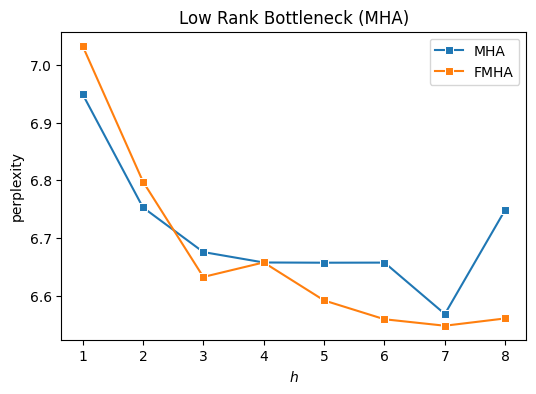

In [14]:
# Experiment 1 Results
# %%script false --no-raise-error
fig, ax = plt.subplots(1,1,figsize=(6,4))
sns.lineplot(df1.iloc[:-3], x='n_head', y='perplexity', marker='s', ax=ax, label="MHA")
sns.lineplot(df2, x='n_head', y='perplexity', marker='s', ax=ax, label="FMHA")
ax.set_xlabel(r"$h$")
ax.set_ylabel("perplexity")
ax.set_title("Low Rank Bottleneck (MHA)")
plt.savefig("images/lrb_mha_fhma.png")
# plt.show()

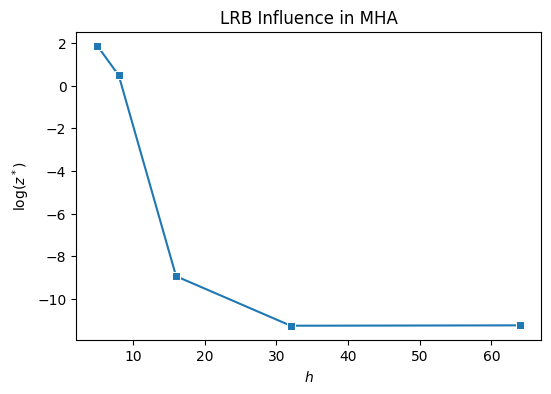

In [27]:
# %%script false --no-raise-error
fig,ax = plt.subplots(1,1,figsize=(6,4))
sns.lineplot(df3, x='n_head', y='log_min_opt_val', ax=ax, marker='s')
ax.set_title("LRB Influence in MHA")
ax.set_ylabel(r"$\log(z^*)$")
ax.set_xlabel(r"$h$")
# plt.savefig("images/lrb_opt_mha.png")
plt.show()